<a href="https://colab.research.google.com/github/BhavyaKansal20/DeepLearning/blob/main/Iris_ANN_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Lets first import all the basic libraries we gonna use**

In [107]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.linear_model import Perceptron
from sklearn.metrics import mean_squared_error, r2_score , classification_report , accuracy_score
import tensorflow as tf
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.utils import to_categorical

# **After that we will work on Iris dataset to start and make a simple basic ANN Project first**

In [108]:
dataset = pd.read_csv("/content/iris.csv")
dataset.head(10)

,sepal_lenght,sepal_width,petal_lengh,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa
5,5.4,3.9,1.7,0.4,Iris-setosa
6,4.6,3.4,1.4,0.3,Iris-setosa
7,5.0,3.4,1.5,0.2,Iris-setosa
8,4.4,2.9,1.4,0.2,Iris-setosa
9,4.9,3.1,1.5,0.1,Iris-setosa


In [109]:
dataset["Species"].value_counts()

,count
Species,
Iris-setosa,50
Iris-versicolor,50
Iris-virginica,50


In [110]:
dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_lenght  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_lengh   150 non-null    float64
 3   petal_width   150 non-null    float64
 4   Species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


In [111]:
dataset.isnull().sum()

,0
sepal_lenght,0
sepal_width,0
petal_lengh,0
petal_width,0
Species,0


In [112]:
dataset.describe()

,sepal_lenght,sepal_width,petal_lengh,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


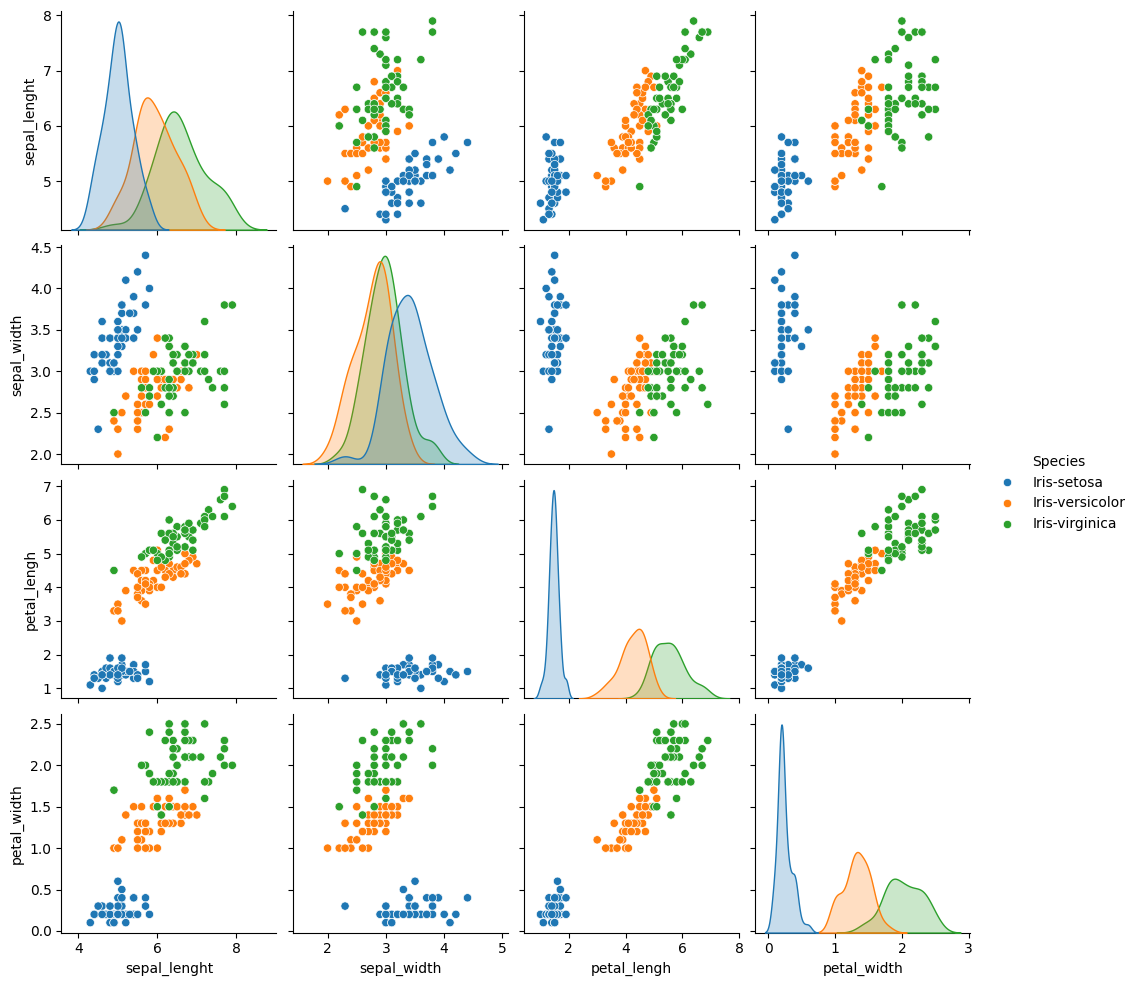

In [113]:
sns.pairplot(dataset , hue = "Species")
plt.show()

In [114]:
x = dataset.iloc[:,:-1]
y = dataset["Species"]

In [115]:
encoder = LabelEncoder()
y_encoded = encoder.fit_transform(y)

In [116]:
x_train , x_test , y_train ,y_test = train_test_split( x , y_encoded , test_size=0.2 , random_state=42 , stratify= y_encoded)

In [117]:
ss = StandardScaler()
x_train = ss.fit_transform(x_train)
x_test = ss.transform(x_test)

In [118]:
perceptron = Perceptron(max_iter=1000 , random_state=42)
perceptron.fit(x_train , y_train)

Perceptron(random_state=42)

In [119]:
y_pred = perceptron.predict(x_test)

In [120]:
accuracy_score(y_test , y_pred)

0.8666666666666667

In [121]:
print(classification_report(y_test , y_pred))

              precision    recall  f1-score   support

           0       0.83      1.00      0.91        10
           1       0.88      0.70      0.78        10
           2       0.90      0.90      0.90        10

    accuracy                           0.87        30
   macro avg       0.87      0.87      0.86        30
weighted avg       0.87      0.87      0.86        30



In [150]:
y_train_cat = to_categorical(y_train , num_classes=3)
y_test_cat = to_categorical(y_test , num_classes=3)

In [151]:
model = Sequential(
    [Dense( 16 , input_dim = 4 , activation="relu"),
    Dense( 8 , activation="relu"),
    Dense( 3 , activation='softmax')]
)

In [152]:
model.compile(
    optimizer="adam",
    loss = "categorical_crossentropy",
    metrics = ["accuracy"]
)

In [153]:
history = model.fit(
    x_train_scaled.astype(np.float32) , y_train_cat ,
    epochs = 60 ,
    batch_size = 10 ,
    validation_split = 0.2 ,
    verbose =1
)

Epoch 1/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 4s 102ms/step - accuracy: 0.3958 - loss: 1.0478 - val_accuracy: 0.4583 - val_loss: 1.0007
Epoch 2/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 1s 35ms/step - accuracy: 0.5417 - loss: 0.9939 - val_accuracy: 0.5833 - val_loss: 0.9494
Epoch 3/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.5625 - loss: 0.9435 - val_accuracy: 0.6250 - val_loss: 0.8990
Epoch 4/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.6250 - loss: 0.8932 - val_accuracy: 0.6250 - val_loss: 0.8495
Epoch 5/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.6562 - loss: 0.8404 - val_accuracy: 0.7917 - val_loss: 0.7993
Epoch 6/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - accuracy: 0.6875 - loss: 0.7892 - val_accuracy: 0.7917 - val_loss: 0.7507
Epoch 7/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 0.7604 - loss: 0.7405 - val_accuracy: 0.7917 - val_loss: 0.7059
Epoch 8/60
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - accuracy: 0.8229 - loss: 0.6972 - val_accuracy: 0.7917 - 

In [155]:
 loss , acc = model.evaluate(x_test_scaled.astype(np.float32) , y_test_cat , verbose =1)
print(f"Loss : {loss*100}* , Accuracy : {acc*100}**")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.9333 - loss: 0.1762
Loss : 17.615094780921936* , Accuracy : 93.33333373069763**


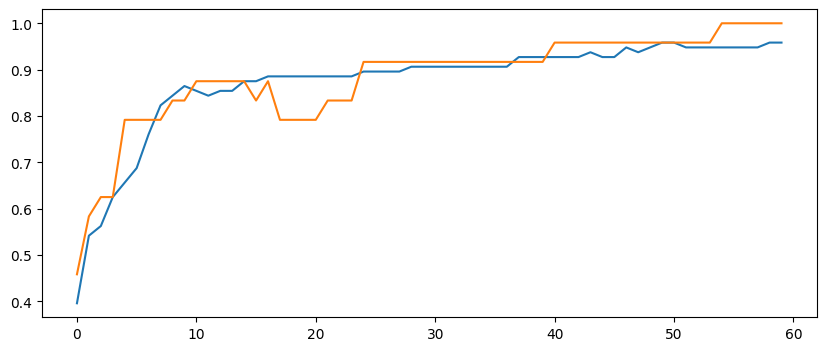

In [157]:
plt.figure(figsize=(10,4))
plt.plot(history.history["accuracy"] , label ="train_acc")
plt.plot(history.history["val_accuracy"] , label ="val_acc")
plt.show()